# Notebook paraimplementar y analizar un modelo de regresion lineal

El modelo sera entrenado y analizado de un dataset disponible en Kaggle, el cual es: 
- Student Performance (Multiple Linear Regression)

El presente documento presenta tres secciones
- Analisis de datos EDA al datset
- Entrenamiento
- Validacion del modelo

## Preparativos

### Importe del dataset desde la API de Kaggle

In [49]:
#Librerias e importes necesarios
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:


# Descargar dataset
path = kagglehub.dataset_download(
    "nikhil7280/student-performance-multiple-linear-regression"
)

print("Dataset descargado en:", path)

# Ver qué archivos contiene
print(os.listdir(path))

Dataset descargado en: /Users/danielmendez/.cache/kagglehub/datasets/nikhil7280/student-performance-multiple-linear-regression/versions/1
['Student_Performance.csv']


### Creacion del dataset

In [51]:
df = pd.read_csv(os.path.join(path, "Student_Performance.csv"))

print(df.head())

   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  


## Analisis de datos

### Descripcion del dataset
El conjunto de datos sobre el rendimiento estudiantil está diseñado para examinar los factores que influyen en el rendimiento académico de los estudiantes. Este conjunto de datos consta de 10.000 registros de estudiantes; cada registro contiene información sobre diversas variables predictoras y un índice de rendimiento.

### Variables:
- *Hours Studied:* El número total de horas que cada estudiante dedicó a estudiar.
- *Previous Scores:* Las calificaciones obtenidas por los estudiantes en exámenes previos.
- *Extracurricular Activities:* Si el estudiante participa en actividades extracurriculares (Sí o No).
- *Sleep Hours:* El promedio de horas de sueño diario del estudiante.
- *Papers Practiced:* El número de cuestionarios de práctica que el estudiante completó.

## Target Variable (Etiqueta):

*Performance Index:* Una medida del rendimiento general de cada estudiante. El índice de rendimiento representa el desempeño académico del estudiante y se ha redondeado al número entero más cercano. El índice oscila entre 10 y 100; los valores más altos indican un mejor rendimiento.

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


Nuestro dataset contiene 6 features, de lascuales:
- 4 son Integers
- 1 es de tipo flotante
- 1 es de tipo objeto, problamente sea necesario analizar y transformar esta caracteristica

Ademas hay 10 mil entradas y no parecen haber valores nulos ni faltantes

In [53]:
print(df.isnull().sum())
print("Duplicados:", df.duplicated().sum())

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64
Duplicados: 127


Sin valores nulos

In [54]:
df["Extracurricular Activities"]

0       Yes
1        No
2       Yes
3       Yes
4        No
       ... 
9995    Yes
9996    Yes
9997    Yes
9998    Yes
9999     No
Name: Extracurricular Activities, Length: 10000, dtype: object

Esta caracteristica es de tipo booleana textual, por lo que es oportuno transformarla a formato 1 y 0 para su correcto manejo a futuro

In [55]:
df["Extracurricular Activities"] = (
    df["Extracurricular Activities"]
    .str.strip()
    .map({"Yes": 1, "No": 0})
)
df["Extracurricular Activities"]

0       1
1       0
2       1
3       1
4       0
       ..
9995    1
9996    1
9997    1
9998    1
9999    0
Name: Extracurricular Activities, Length: 10000, dtype: int64

In [56]:
df.describe()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,0.494800,6.530600,4.583300,55.224800
std,2.589309,17.343152,0.499998,1.695863,2.867348,19.212558
min,1.000000,40.000000,0.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,0.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,0.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,1.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,1.000000,9.000000,9.000000,100.000000


El codigo anterior nos dice difeerentes caracteristicas estadisticas de los distintos features:
- La media de horas estudiada es casi 5, ademas las horas en el dataset varian en 2.5, el minimo de horas estudiadas es 1 y el maximo 9. La mayoria duermen entre 5 y 8 horas   
- La media de notas anteriores es de 69.44, la nota minima registrada es 40 y maxima 99
- La mitad de estudiantes realiza actividades curriculares, la otra no
- La media de horas de sueño es de 6.5, la minima de 4 y la maxima de 9
- Los estudiantes tienen una media de 4.5 hojas de practica, mientras hay unos que no realizan y otros que han realizado hasta 9
- Rendimiento promedio es de 55.2, mientras hay estudiantes con un rendimiento de 10, hay otros con rendimiento de 100. Pero hay una desviación estándar bastante grande (19.21), lo que indica que los resultados están bastante dispersos.

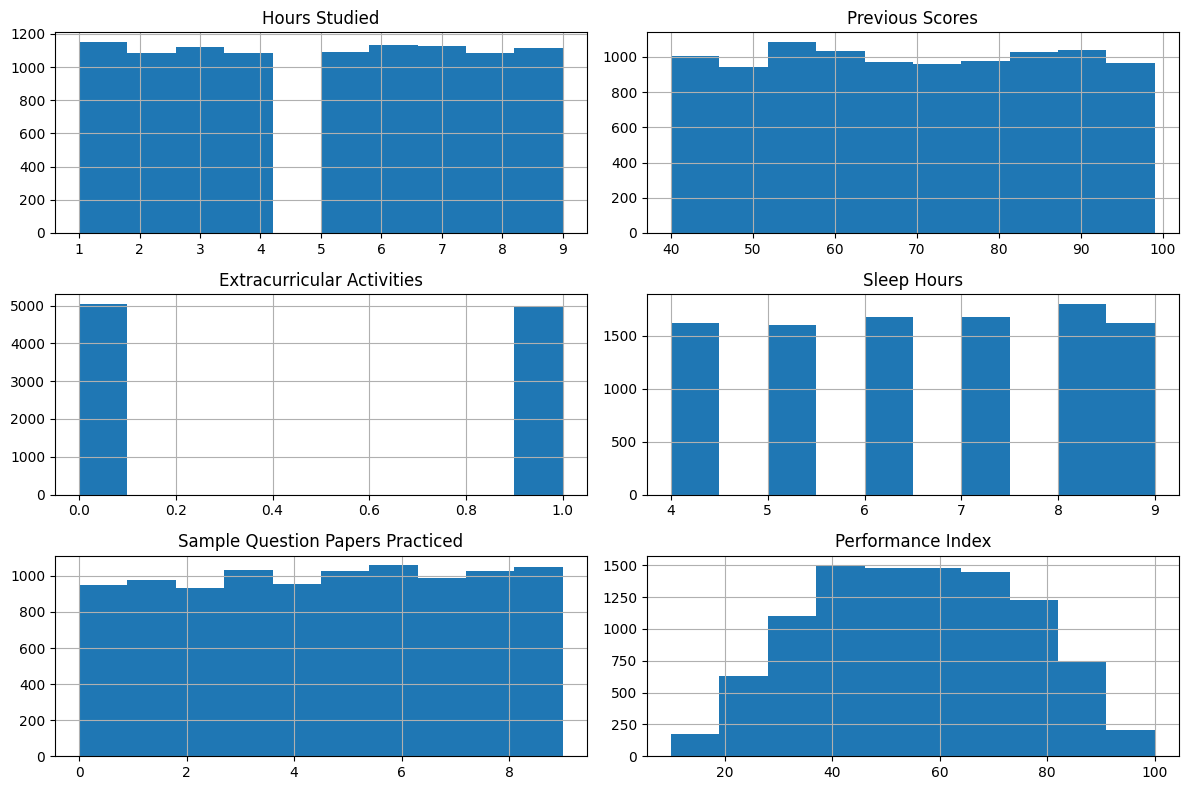

In [57]:
df.hist(figsize=(12, 8), bins=10)

plt.tight_layout()
plt.show()

### Analisis por Histograma
#### Horas de estudio
- La distribucion es bastatante uniforme entre 1 y 9 horas
- No se observan valores atipicos ni concentracion extrema en un punto
- Todos contienen cantidades parecidas
#### Notas anteriores
- También presenta una distribución bastante uniforme entre 40 y 99.
#### Actividades extracurriculares
- Al ser una variable booleana (1 y 0) obviamente solo vemos distribucion en estos puntos, igualmente tenemos cantidades parecidas en ambos
#### Horas de sueño
- Tenemos valores entre 4 y 9 horas y la distribución también es bastante uniforme.
#### Hojas de prueba de practica
- Nuevamente tenemos una distribución bastante uniforme entre 0 y 9
- Hay estudiantes que no practican ningún paper y estudiantes que practican hasta 9.
#### Indice de rendimiento
- Observamos una especie de distribución aproximadamente normal, centrada alrededor de 50–60.
- La mayoría de los estudiantes tiene un Performance Index aproximadamente entre: 30 y 80
- y tenemos pocos estudiantes cerca de los extremos: 0-20 y 90-100

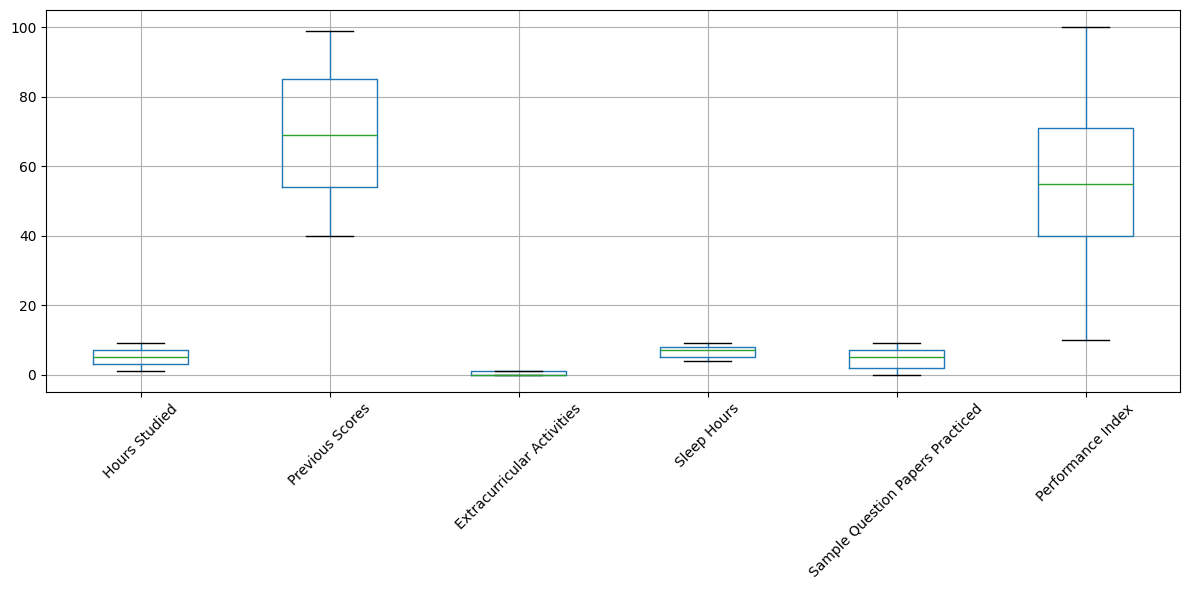

In [58]:
plt.figure(figsize=(12, 6))

df.boxplot()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

No se observan "Outliers" ni datos anomalos.

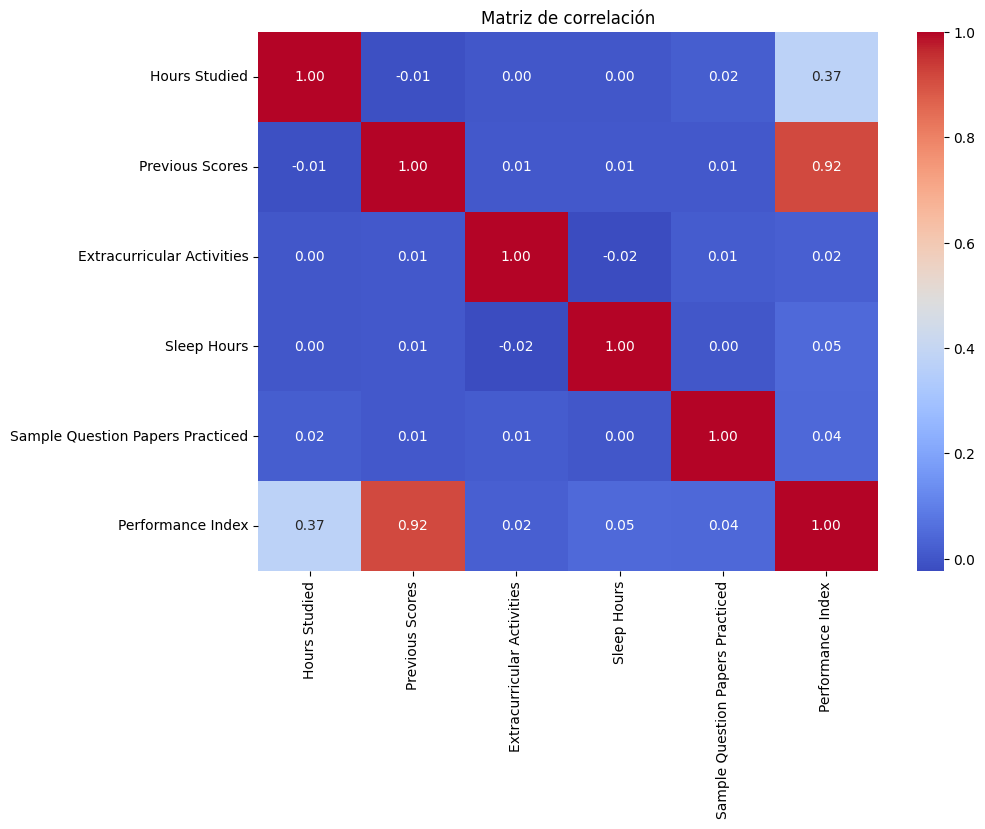

In [59]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.show()

Podemos ver una correlacion fuerte entre Performance Index y dos variables:
1. Previous score: La mas fuerte y demuestra un gran correlacion lineal
2. Hour studied: No es tan fuerte como la anterior, pero muestra una fuerte relacion entre ambas variables
3. Las demas variables no muestran una correlacion fuerte

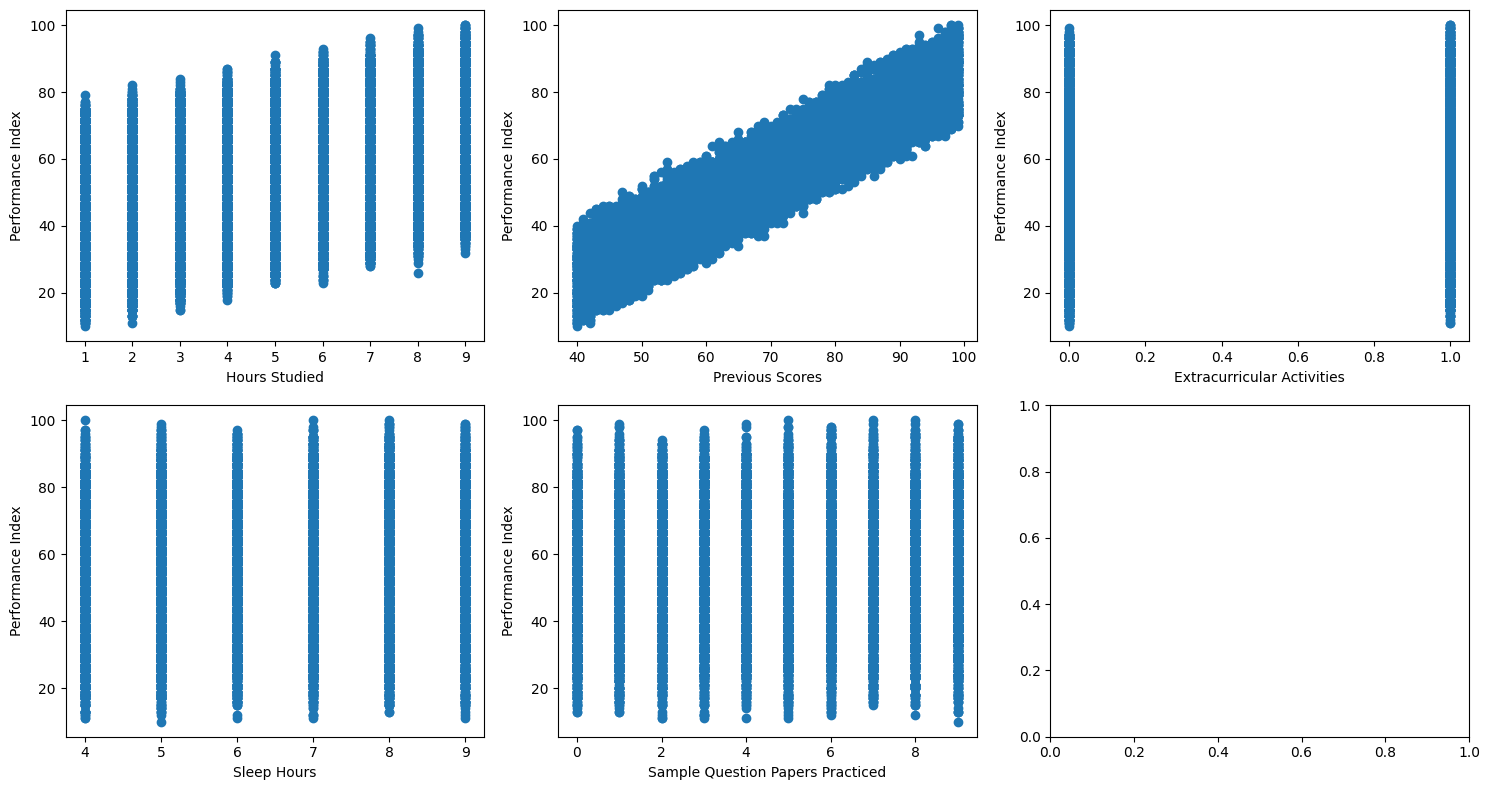

In [61]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

variables = [
    "Hours Studied",
    "Previous Scores",
    "Extracurricular Activities",
    "Sleep Hours",
    "Sample Question Papers Practiced"
]

for ax, variable in zip(axes.flat, variables):
    ax.scatter(df[variable], df["Performance Index"])
    ax.set_xlabel(variable)
    ax.set_ylabel("Performance Index")

plt.tight_layout()
plt.show()

Estos graficos demuestran mejor que si hay una fuerte relacion lineal entre estas variables.
Por lo que se espera que tengan una mayor influencia en la predicción del rendimiento.

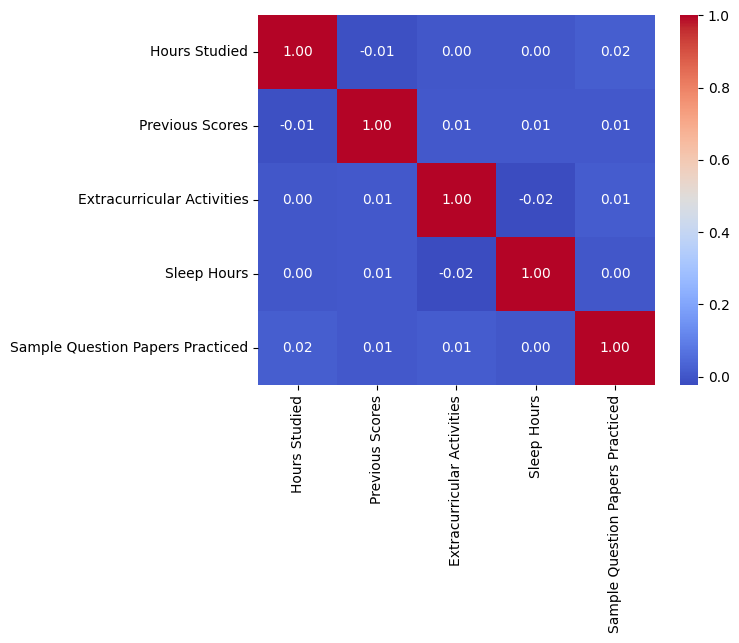

In [62]:
sns.heatmap(
    df.drop(columns=["Performance Index"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

No tenemos evidencia de multicolinealidad fuerte a partir de esa matriz.

## Division del dataset
### 1) Muestreo aleatorio (Random Sampling).
El conjunto de datos debe dividirse en 70% entrenamiento,
15% validacion y 15% prueba. No esta permitido el uso de funciones de scikit-learn como train_test_split.

In [60]:
import numpy as np

# Número total de observaciones
n = len(df)

# Crear índices 0, 1, 2, ..., n-1
indices = np.arange(n)

# Barajar los índices aleatoriamente
np.random.seed(42)
np.random.shuffle(indices)

# Calcular tamaños
train_size = int(0.70 * n)
val_size = int(0.15 * n)

# Separar índices
train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

# Crear los datasets
train = df.iloc[train_indices]
validation = df.iloc[val_indices]
test = df.iloc[test_indices]

print("Train:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))

Train: 7000
Validation: 1500
Test: 1500
